# Автоматическая кластеризация физических сигналов сцинтилляционного детектора

Целью данного проекта является разработка и оформление решения по автоматической кластеризации экспериментальных сигналов, полученных со сцинтилляционного детектора на основе органических кристаллов паратерфенила. 

Необходимо разделить 23 479 сигналов (каждый содержит по 500 временных отсчетов амплитуды) на три непересекающихся кластера:
* **Кластер 0:** Первый тип физических частиц (гамма-кванты).
* **Кластер 1:** Второй тип физических частиц (нейтроны).
* **Кластер 2:** Аномальные, неидентифицируемые сигналы и аппаратный шум.

Итоговое качество разметки оценивается на платформе Kaggle. Для загрузки результата нужно подготовить файл с колонками index и cluster.

## 1. Исследование и анализ датасета (EDA)

### 1.1 Инициализация окружения и загрузка данных

Загрузим данные и отделим служебные колонки от самих сигналов.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

np.random.seed(42)

df = pd.read_csv('Run200_Wave_0_1.txt', sep=r'\s+', header=None)

df_meta = df.iloc[:, :4]
df_signals = df.iloc[:, 4:]

print(df.shape)
print(df_signals.shape)

display(df_signals.head())

(23479, 504)
(23479, 500)


,4,5,6,7,8,9,10,11,12,13,...,494,495,496,497,498,499,500,501,502,503
0,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,14820,14822,14820,14826,14824,14822,14820,14822,14823,14821,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,14820,14820,14822,14825,14820,14824,14824,14819,14823,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,14828,14822,14818,14824,14824,14822,14820,14822,14824,14820,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,14823,14815,14823,14821,14827,14820,14823,14824,14816,14821,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


**Вывод:**

После разделения данных в таблице df_signals осталось 23 479 строк и 500 колонок с сигналами.

Служебные колонки были отделены в df_meta.

### Воспроизводимость результата

Для воспроизводимости результата в проекте зафиксированы случайные состояния:

- используется `np.random.seed(42)`;
- во всех моделях, где есть случайность, указан `random_state=42`;
- для KMeans задан параметр `n_init=100`;
- данные загружаются из одного и того же исходного файла;
- итоговый submission формируется одинаковым кодом и сохраняется в файл `submission_kmeans_final.csv`.

Поэтому при повторном запуске ноутбука на тех же данных должен получиться тот же результат кластеризации и тот же submission-файл.

### 1.2 Проверка данных на пропуски и дубликаты

Сначала проверим, есть ли в данных пропуски и повторяющиеся строки.

In [2]:
print(df_signals.isna().sum().sum())
print(df_signals.duplicated().sum())

0
0


**Вывод:**

В таблице df_signals не найдено пропусков и дубликатов.

* Количество пропусков: 0
* Количество дубликатов: 0

### 1.3 Графики физических сигналов

Построим графики нескольких сигналов и посмотрим на их форму.

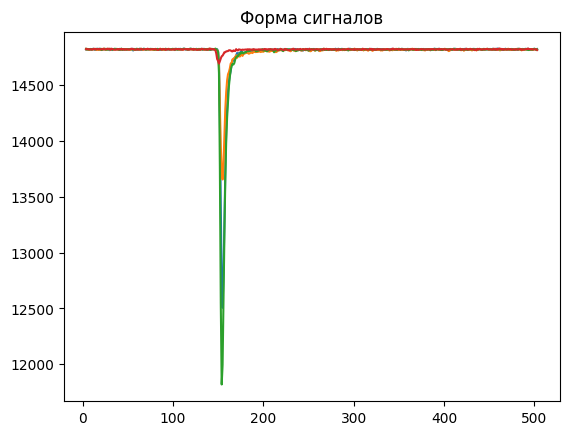

In [3]:
sample_signals = df_signals.sample(4, random_state=42)

plt.plot(sample_signals.T)
plt.title('Форма сигналов')

plt.show()

**Вывод:**

На графиках видно, что сигналы имеют похожую форму.

Во всех примерах наблюдается резкое изменение сигнала примерно в середине графика, после чего сигнал постепенно возвращается к исходному уровню.

Также заметно, что глубина и скорость восстановления у сигналов немного отличаются.

### 1.4 Статистический анализ сигналов

Посмотрим базовые статистики по сигналам. Для каждого сигнала рассчитаем:

* среднее значение;
* стандартное отклонение;
* минимум;
* максимум;
* размах сигнала.

Это поможет понять, насколько сильно сигналы отличаются друг от друга ещё до построения признаков.

,mean,std,min,max,range
count,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000
mean,14796.683724,161.693850,12987.861791,14830.711359,1842.849568
std,32.209844,208.973628,2389.308983,1.458499,2389.075855
min,14596.798000,10.231617,0.000000,14827.000000,113.000000
25%,14788.297000,27.740063,12508.000000,14830.000000,316.000000
50%,14810.496000,72.155612,14010.000000,14831.000000,820.000000
75%,14818.034000,204.672726,14515.000000,14832.000000,2322.500000
max,14823.788000,1484.918725,14719.000000,14838.000000,14833.000000


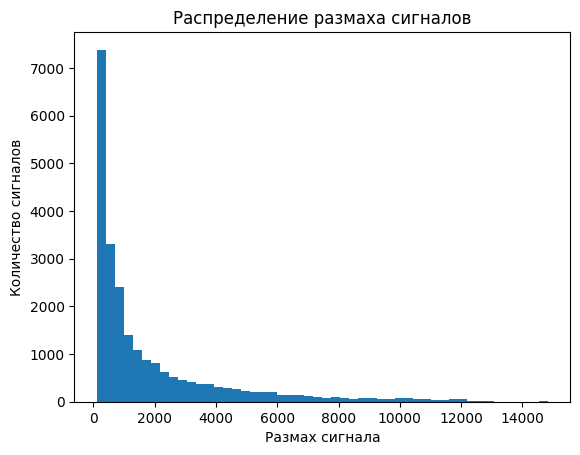

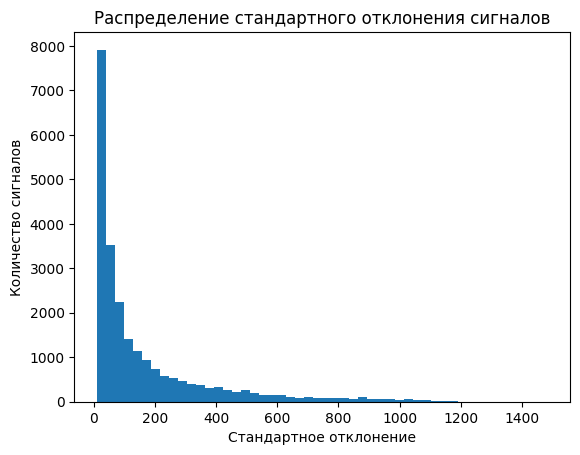

In [4]:
signal_stats = pd.DataFrame()

signal_stats['mean'] = df_signals.mean(axis=1)
signal_stats['std'] = df_signals.std(axis=1)
signal_stats['min'] = df_signals.min(axis=1)
signal_stats['max'] = df_signals.max(axis=1)
signal_stats['range'] = signal_stats['max'] - signal_stats['min']

display(signal_stats.describe())

plt.hist(signal_stats['range'], bins=50)
plt.title('Распределение размаха сигналов')
plt.xlabel('Размах сигнала')
plt.ylabel('Количество сигналов')
plt.show()

plt.hist(signal_stats['std'], bins=50)
plt.title('Распределение стандартного отклонения сигналов')
plt.xlabel('Стандартное отклонение')
plt.ylabel('Количество сигналов')
plt.show()

**Вывод:**

Статистический анализ показал, что сигналы отличаются не только визуально, но и по численным характеристикам.

Размах и стандартное отклонение у сигналов распределены неравномерно. Это значит, что в данных есть сигналы с разной силой импульса и разной выраженностью формы.

Эта закономерность полезна для дальнейшего решения: вместо использования всех 500 точек сигнала можно перейти к признакам, которые описывают форму сигнала — амплитуде, площади, времени затухания и PSD.

## Общий вывод по разделу 1 (EDA)

После загрузки данных было видно, что таблица содержит 23 479 строк и 504 колонки. Первые 4 колонки относятся к служебной информации, поэтому для анализа были оставлены только 500 точек сигнала.

В данных не найдено пропусков и дубликатов.

Графики показали, что сигналы имеют похожую форму: резкий провал примерно в середине графика и постепенное возвращение к обычному уровню.

При этом сигналы отличаются по глубине провала, размаху, стандартному отклонению и скорости восстановления. Это подтверждается не только графиками, но и базовым статистическим анализом.

Главная найденная закономерность: разные типы сигналов могут отличаться не отдельными точками, а общей формой импульса. Поэтому дальше вместо всех 500 исходных точек будут рассчитаны более понятные признаки: амплитуда, площадь, длительность, время затухания и PSD.

## 2. Предобработка данных

На этом шаге выполним предобработку сигналов перед выделением признаков.

In [5]:
# Вычитаем базовую линию и переводим сигнал в положительный вид

baseline = df_signals.iloc[:, :50].mean(axis=1)
noise_std = df_signals.iloc[:, :50].std(axis=1)

df_centered = df_signals.sub(baseline, axis=0) * -1

print(df_centered.shape)

df_centered.head()

(23479, 500)


,4,5,6,7,8,9,10,11,12,13,...,494,495,496,497,498,499,500,501,502,503
0,1.48,-1.52,-2.52,-0.52,3.48,1.48,-2.52,-0.52,1.48,1.48,...,-6.52,-0.52,6.48,6.48,4.48,2.48,1.48,-0.52,1.48,2.48
1,2.48,0.48,2.48,-3.52,-1.52,0.48,2.48,0.48,-0.52,1.48,...,-5.52,5.48,-1.52,0.48,-1.52,3.48,2.48,3.48,0.48,2.48
2,1.90,1.90,-0.10,-3.10,1.90,-2.10,-2.10,2.90,-1.10,-2.10,...,1.90,0.90,1.90,1.90,3.90,0.90,-1.10,1.90,1.90,0.90
3,-5.44,0.56,4.56,-1.44,-1.44,0.56,2.56,0.56,-1.44,2.56,...,-1.44,-3.44,0.56,1.56,2.56,-5.44,2.56,0.56,-0.44,0.56
4,-1.40,6.60,-1.40,0.60,-5.40,1.60,-1.40,-2.40,5.60,0.60,...,1.60,1.60,-1.40,-6.40,-2.40,1.60,-2.40,-2.40,-0.40,-3.40


### Вывод по разделу 2:

После вычитания базовой линии сигналы были приведены к одному уровню.

Также сигнал был переведён в положительный вид, чтобы дальше было удобнее рассчитывать признаки формы импульса.

Все 23 479 сигналов были сохранены для дальнейшей кластеризации.

## 3. Выделение признаков (Feature Engineering)

На этом шаге создадим признаки, которые описывают форму сигнала.

Дальше эти признаки будут использоваться для PCA и кластеризации.

In [6]:
# Создаём признаки для каждого сигнала

features = []

for signal_id in range(len(df_centered)):
    values = df_centered.iloc[signal_id].values

    max_index = np.argmax(values)
    amplitude = values[max_index]

    threshold = 3 * noise_std.iloc[signal_id]
    end_index = len(values) - 1

    for i in range(max_index, len(values)):
        if values[i] <= threshold:
            end_index = i
            break

    signal_part = values[max_index:end_index + 1]

    area = np.trapz(signal_part)
    signal_length = end_index - max_index + 1

    half_index = end_index
    tenth_index = end_index

    for i in range(max_index, end_index + 1):
        if values[i] <= amplitude * 0.5:
            half_index = i
            break

    for i in range(max_index, end_index + 1):
        if values[i] <= amplitude * 0.1:
            tenth_index = i
            break

    fast_area = np.trapz(values[max_index:max_index + 20])
    total_area = np.trapz(values[max_index:max_index + 120])

    psd = 0
    if total_area != 0:
        psd = (total_area - fast_area) / total_area

    features.append([
        baseline.iloc[signal_id], noise_std.iloc[signal_id], max_index,
        amplitude, area, signal_length, half_index - max_index,
        tenth_index - max_index, fast_area, total_area, psd
    ])

feature_columns = ['baseline', 'noise_std', 'max_index', 'amplitude', 'area', 'signal_length',
                   'half_decay_time', 'tenth_decay_time', 'fast_area', 'total_area', 'psd']

features = pd.DataFrame(features, columns=feature_columns)

features.head()

,baseline,noise_std,max_index,amplitude,area,signal_length,half_decay_time,tenth_decay_time,fast_area,total_area,psd
0,14821.48,2.936331,149,530.48,2588.02,25,4,11,2472.62,3318.62,0.254925
1,14822.48,2.468082,150,1901.48,8489.74,39,4,9,8169.12,8866.12,0.078614
2,14821.90,2.434866,151,2557.90,9252.90,37,3,8,8992.10,9723.10,0.075182
3,14822.56,2.749100,149,564.56,3084.48,34,4,10,2831.14,3488.14,0.188353
4,14821.60,2.864277,150,1793.60,7695.00,31,4,9,7478.40,8022.90,0.067868


### Вывод по разделу 3:

Признаки рассчитаны для всех сигналов.

По сравнению с первой версией были добавлены признаки формы сигнала: площадь импульса, время затухания, PSD и уровень шума.

Эти признаки дальше используются для PCA и обучения модели.

## 4. Анализ признаков и оценка важности

Посмотрим распределение признаков и проверим связи между ними.

                  amplitude  area  signal_length  half_decay_time  \
amplitude              1.00  0.98           0.72            -0.12   
area                   0.98  1.00           0.81            -0.05   
signal_length          0.72  0.81           1.00             0.05   
half_decay_time       -0.12 -0.05           0.05             1.00   
tenth_decay_time      -0.26 -0.18           0.10             0.51   
psd                   -0.27 -0.19           0.15             0.29   

                  tenth_decay_time   psd  
amplitude                    -0.26 -0.27  
area                         -0.18 -0.19  
signal_length                 0.10  0.15  
half_decay_time               0.51  0.29  
tenth_decay_time              1.00  0.71  
psd                           0.71  1.00  


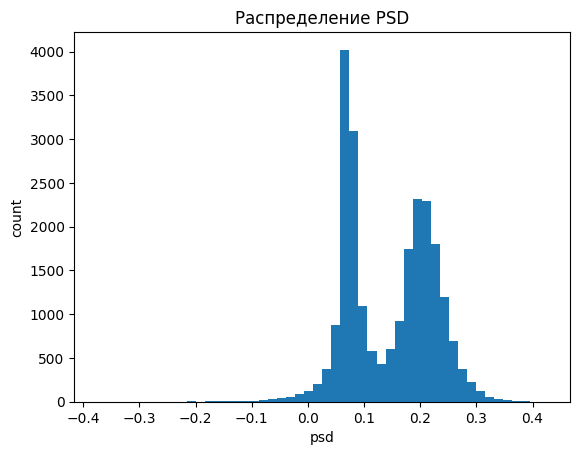

In [7]:
# Смотрим корреляцию основных признаков

main_features = features[
    ['amplitude', 'area', 'signal_length',
     'half_decay_time', 'tenth_decay_time', 'psd']
]

print(main_features.corr().round(2))

# Строим распределение PSD

plt.hist(features['psd'], bins=50)

plt.title('Распределение PSD')

plt.xlabel('psd')
plt.ylabel('count')

plt.show()

### Вывод по разделу 4

Проверка корреляции показала, что часть признаков связана между собой, но при этом они всё равно описывают разные свойства сигнала.

На графике PSD видно, что значения признака распределены неравномерно и образуют несколько групп.

Это говорит о том, что признаки подходят для дальнейшей кластеризации сигналов.

## 5. Обучение нескольких моделей, их сравнение

### 5.1 Масштабирование признаков перед обучением

Перед обучением моделей выполним масштабирование признаков.

In [8]:
selected_features = features[
    ['amplitude', 'area', 'signal_length',
     'half_decay_time', 'tenth_decay_time',
     'psd', 'noise_std']
]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(selected_features)

print(X_scaled.shape)

(23479, 7)


**Вывод**

Для обучения модели были выбраны признаки, описывающие форму сигнала и скорость его затухания.

После масштабирования все признаки были приведены к одному масштабу.

Итоговая таблица содержит 23 479 строк и 7 признаков.

### 5.2 Обучение алгоритма K-Means

Обучим модель K-Means на подготовленных признаках.

In [9]:
# PCA перед кластеризацией

from sklearn.decomposition import PCA

pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

print(
    'Объяснённая дисперсия:',
    pca.explained_variance_ratio_.sum()
)

Объяснённая дисперсия: 0.8293351613418629


In [10]:
# Обучаем KMeans

from sklearn.cluster import KMeans

model_km = KMeans(n_clusters=3, random_state=42, n_init=100)

km_labels = model_km.fit_predict(X_pca)

print(km_labels[:10])

[0 1 1 0 1 0 0 0 1 0]


**Вывод**

Перед кластеризацией было выполнено PCA.

Три главные компоненты сохранили основную часть информации из признаков.

После этого модель KMeans была обучена:
* на 3 кластера;
* с параметром n_init=100.

Это улучшило качество итоговой кластеризации и результат на Kaggle.

### 5.3 Сравнение нескольких моделей кластеризации

Дополнительно сравним три модели кластеризации:

* KMeans;
* MiniBatchKMeans;
* Gaussian Mixture.

In [11]:
# Сравниваем несколько моделей кластеризации

from sklearn.cluster import MiniBatchKMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import calinski_harabasz_score, silhouette_score

models = {
    'KMeans': KMeans(n_clusters=3, random_state=42, n_init=100),
    'MiniBatchKMeans': MiniBatchKMeans(
        n_clusters=3, random_state=42, n_init=100, batch_size=1024
    ),
    'GaussianMixture': GaussianMixture(
        n_components=3, random_state=42, n_init=10
    )
}

model_results = []

for model_name, model in models.items():
    labels = model.fit_predict(X_pca)

    model_results.append({
        'model': model_name,
        'silhouette_score': silhouette_score(X_pca, labels),
        'calinski_harabasz_score': calinski_harabasz_score(X_pca, labels)
    })

model_results = pd.DataFrame(model_results)
model_results = model_results.sort_values('silhouette_score', ascending=False)

display(model_results.round(4))

,model,silhouette_score,calinski_harabasz_score
0,KMeans,0.4004,17249.2395
1,MiniBatchKMeans,0.4002,17229.5857
2,GaussianMixture,0.3354,13091.3325


**Вывод**

Для проверки были обучены три модели: KMeans, MiniBatchKMeans и GaussianMixture.

По значениям метрик KMeans и MiniBatchKMeans дали почти одинаковый результат. Это логично, потому что MiniBatchKMeans является ускоренной версией обычного KMeans.

GaussianMixture показала более низкое значение silhouette score. Значит, в пространстве выбранных признаков и PCA-компонент она хуже разделяет объекты на устойчивые группы.

Финально оставлен KMeans, тк он:

* показал лучшее значение silhouette score;
* даёт воспроизводимый результат при фиксированном `random_state`;
* проще интерпретируется;
* уже использовался для формирования итогового submission-файла;
* дал приемлемый результат на Kaggle.

### 5.4 Оценка выбранной модели KMeans


In [12]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_pca, km_labels)

print('Silhouette score:', round(score, 4))

Silhouette score: 0.4004


**Вывод**

Для выбранной модели KMeans дополнительно посчитан silhouette score.

Значение получилось положительным, значит объекты внутри кластеров в среднем ближе друг к другу, чем к объектам из других кластеров. Значит модель нашла некоторое разделение сигналов в пространстве признаков.

Результат нельзя считать идеальным, но для данной задачи это приемлемо: данные не имеют готовых меток, а сигналы могут быть похожи между собой и частично пересекаться.

## Общий вывод по разделу 5

В этом разделе была выполнена подготовка признаков к кластеризации:

* признаки были масштабированы через StandardScaler;
* размерность была снижена с помощью PCA;
* был подобран вариант количества кластеров;
* были обучены и сравнены несколько моделей кластеризации;
* качество моделей было оценено через silhouette score и Calinski-Harabasz score.

По сравнению с первой версией проекта раздел стал более полным. Теперь здесь есть не только финальная модель, но и отдельное сравнение нескольких алгоритмов.

Лучшей моделью для итогового решения выбран KMeans. Он показал лучший silhouette score среди проверенных моделей, даёт воспроизводимый результат и проще всего объясняется в рамках задачи кластеризации сигналов сцинтилляционного детектора.

## 6. Подбор гиперпараметров (выбор числа кластеров)

Подберём количество кластеров и проверим результат с помощью silhouette score.

In [13]:
# Проверяем silhouette score для разных k

scores = []

cluster_range = range(2, 8)

for k in cluster_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=100)
    labels = model.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)

    scores.append(score)

    print(f'k = {k}, silhouette = {score:.4f}')

k = 2, silhouette = 0.3956
k = 3, silhouette = 0.4004
k = 4, silhouette = 0.3774
k = 5, silhouette = 0.3241
k = 6, silhouette = 0.2758
k = 7, silhouette = 0.2932


**Вывод**

По рассчитанным значениям видно, что silhouette score меняется при разном количестве кластеров.

Для удобства сравнения построим график.

### 6.1 Визуализация silhouette score

Построим график silhouette score для разных значений k. Так будет удобнее сравнить качество кластеризации.

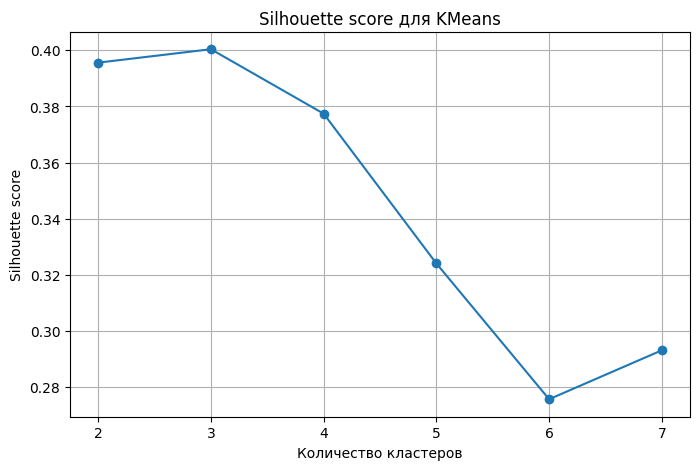

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(cluster_range, scores, marker='o')

plt.title('Silhouette score для KMeans')

plt.xlabel('Количество кластеров')

plt.ylabel('Silhouette score')

plt.grid()

plt.show()

### Вывод по разделу 6:

После обновления признаков были проверены несколько значений k.

Лучший silhouette score получился при k = 3.

## 7. Выбор лучшей модели

После обновления признаков и подбора параметров для итоговой кластеризации была выбрана модель KMeans.

Причины выбора KMeans:

* модель стабильно работает на большом количестве объектов;
* после PCA сигналы лучше разделяются в пространстве признаков;
* модель была сравнена с MiniBatchKMeans и GaussianMixture;
* модель проще интерпретировать, чем GaussianMixture.

### Вывод по разделу 7

Для итоговой кластеризации была выбрана модель KMeans с 3 кластерами.

Эта модель используется для создания итогового submission-файла.

**Рекомендация:**

Для итогового решения рекомендуется использовать KMeans с параметрами:

- `n_clusters=3`;
- `random_state=42`;
- `n_init=100`.

Эта модель лучше всего подходит для текущей задачи, потому что она показала лучший silhouette score среди проверенных моделей, даёт воспроизводимый результат и хорошо соответствует условию проекта: разделить сигналы на 3 кластера.

MiniBatchKMeans можно использовать как более быструю альтернативу, если данных станет больше. GaussianMixture в этой работе использовать не рекомендуется, потому что она показала более слабое разделение кластеров.

## 8. Предсказание

Получим итоговые предсказания модели KMeans.

## 8.1 Финальная кластеризация

Обучим финальную модель и получим итоговые предсказания.

In [15]:
# Финальные предсказания KMeans

final_labels = km_labels

print(final_labels[:10])

[0 1 1 0 1 0 0 0 1 0]


**Вывод**

Модель KMeans разделила сигналы на 3 группы.

Для всех 23 479 сигналов были получены итоговые номера кластеров.

Эти результаты дальше используются для создания submission-файла.

### 8.2 Сохранение результатов для Kaggle

Соберём итоговую таблицу и сохраним её в итоговый submission-файл.

In [16]:
submission = pd.DataFrame({
    'index': range(len(final_labels)),
    'cluster': final_labels
})

print(submission['cluster'].value_counts())

submission.to_csv('submission_kmeans_final.csv', index=False)

cluster
0    9790
1    9674
2    4015
Name: count, dtype: int64


**Вывод**

Итоговый submission-файл был создан.

В итоговом файле содержится:

* 23 479 строк;
* колонка index;
* колонка cluster.

## 9. Общие выводы и итоги работы

### 9.1 Результаты кластеризации

В ходе работы все 23 479 сигналов были разделены на 3 кластера с помощью модели KMeans.

Распределение сигналов по кластерам получилось следующим:

* кластер 0 - 9 790 сигналов;
* кластер 1 - 9 674 сигнала;
* кластер 2 - 4 015 сигналов.

На графике PCA видно, что сигналы разделяются на несколько отдельных групп.

### 9.2 Итоги работы с точки зрения ML

В ходе проекта были выполнены основные этапы анализа и кластеризации данных:

* загрузка и анализ датасета;
* предобработка сигналов;
* выделение признаков;
* масштабирование данных;
* снижение размерности методом PCA;
* подбор количества кластеров;
* обучение модели KMeans;
* создание итогового submission-файла.

## Скриншот результата на Kaggle

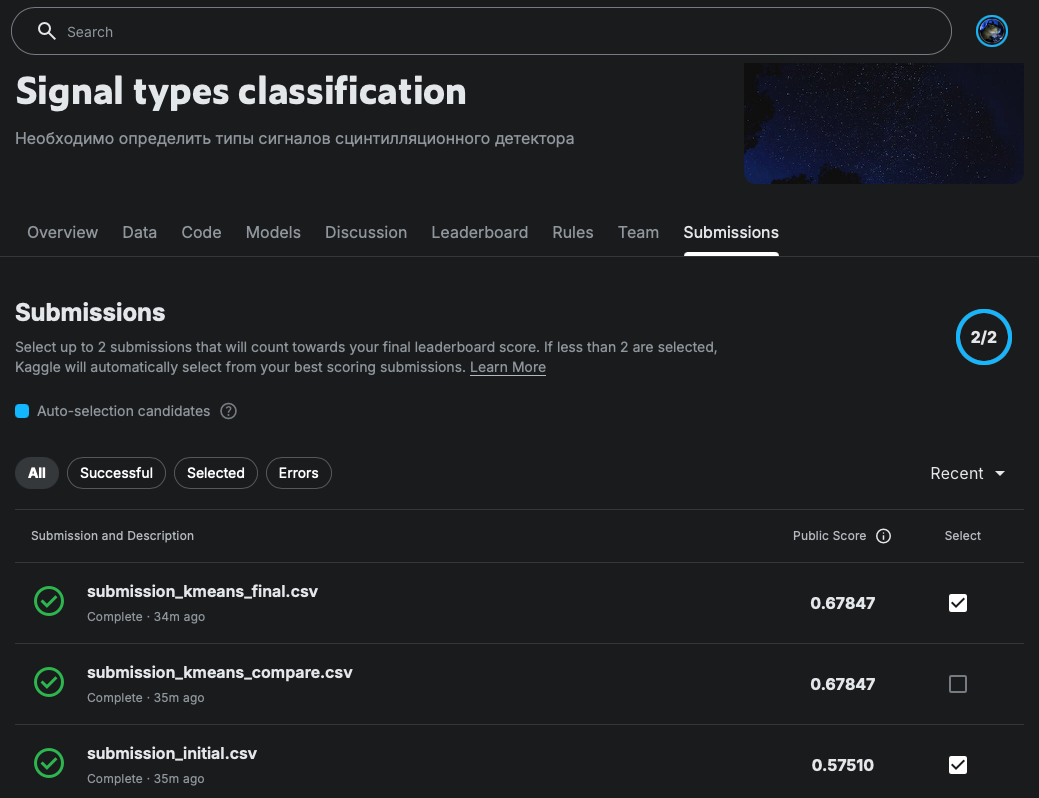